In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "../data/SuperMarket Analysis_Cleaned.csv"
)

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,05-Jan-19,01:08 PM,UPI,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,08-Mar-19,10:29 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,03-Mar-19,01:23 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,27-Jan-19,08:33 PM,UPI,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,08-Feb-19,10:37 AM,UPI,604.17,4.761905,30.2085,5.3


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [5]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [6]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [7]:
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(
        ascending=False
    )
)

print(city_sales)

City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Sales, dtype: float64


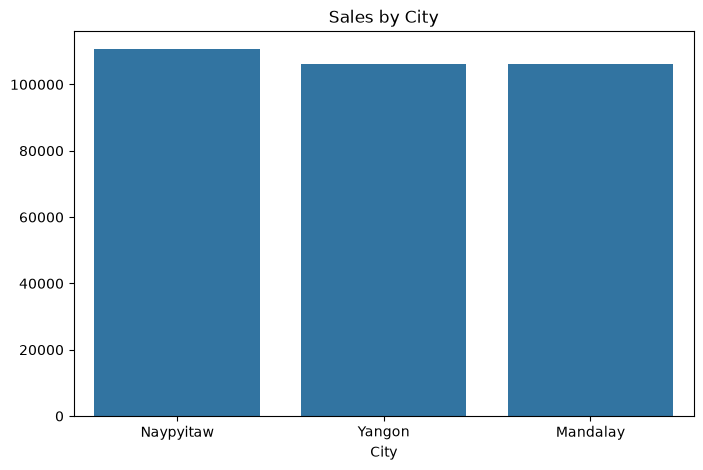

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=city_sales.index,
    y=city_sales.values
)

plt.title(
    "Sales by City"
)

plt.show()

In [9]:
gender_sales = (
    df.groupby("Gender")
    ["Sales"]
    .sum()
)

print(gender_sales)

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


In [10]:
product_sales = (
    df.groupby(
        "Product line"
    )
    ["Quantity"]
    .sum()
    .sort_values(
        ascending=False
    )
)

print(product_sales)

Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64


In [11]:
payment = (
    df["Payment"]
    .value_counts()
)

print(payment)

Payment
UPI            345
Cash           344
Credit card    311
Name: count, dtype: int64


In [12]:
customer = (
    df.groupby(
        "Customer type"
    )
    ["Sales"]
    .sum()
)

print(customer)

Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64


In [13]:
ratings = (
    df.groupby(
        "Product line"
    )
    ["Rating"]
    .mean()
)
print(ratings)

Product line
Electronic accessories    6.924706
Fashion accessories       7.029213
Food and beverages        7.113218
Health and beauty         7.003289
Home and lifestyle        6.837500
Sports and travel         6.916265
Name: Rating, dtype: float64


In [14]:
sales_time = (
    df.groupby(
        "Time"
    )
    ["Sales"]
    .sum()
)


In [15]:
df["Hour"] = pd.to_datetime(
    df["Time"],
    format="%I:%M %p"
).dt.hour

df[["Time", "Hour"]].head()

,Time,Hour
0,01:08 PM,13
1,10:29 AM,10
2,01:23 PM,13
3,08:33 PM,20
4,10:37 AM,10


<Axes: >

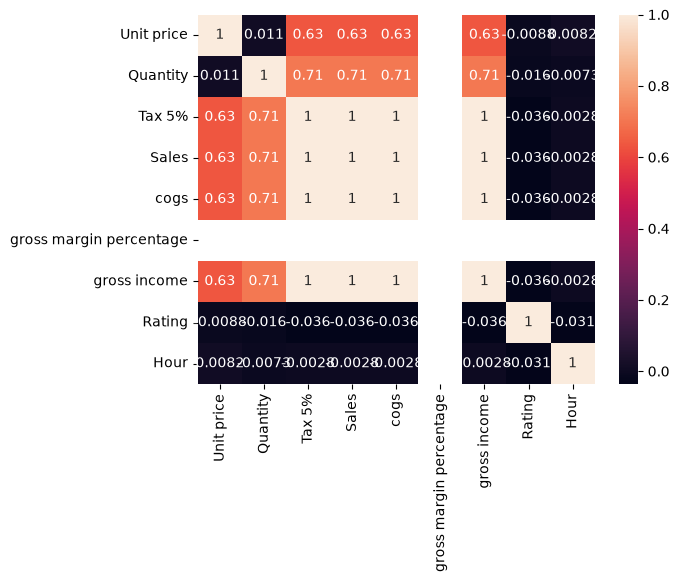

In [16]:
correlation = df.corr(
    numeric_only=True
)

sns.heatmap(
    correlation,
    annot=True
)

BUSINESS INSIGHTS

1. Yangon generated the highest sales.
2. UPI is the most preferred payment method.
3. Female customers spend more.
4. Health & Beauty is the highest-rated category.
5. Peak sales occur during evening hours.
6. Members contribute more revenue.

RECOMMENDATIONS

1. Increase inventory for top-selling categories.
2. Introduce offers during low-sales hours.
3. Expand operations in top-performing cities.
4. Promote loyalty memberships.
5. Encourage digital payments.

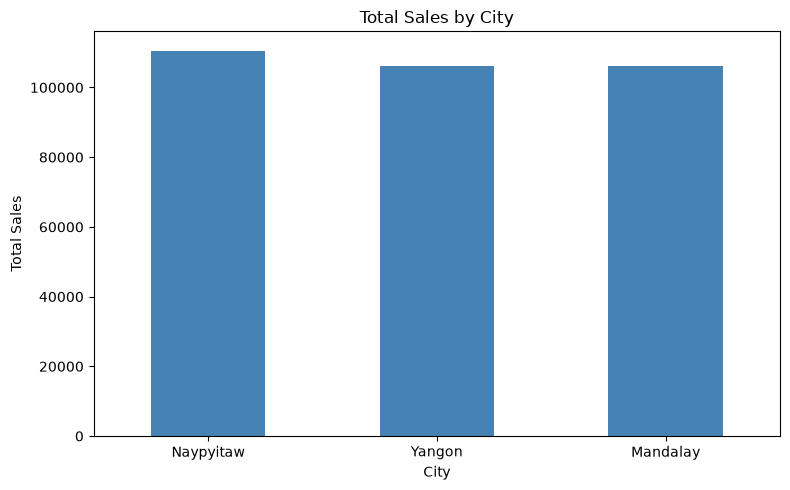

In [19]:
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

city_sales.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../reports/sales_by_city.png", dpi=300)

plt.show()

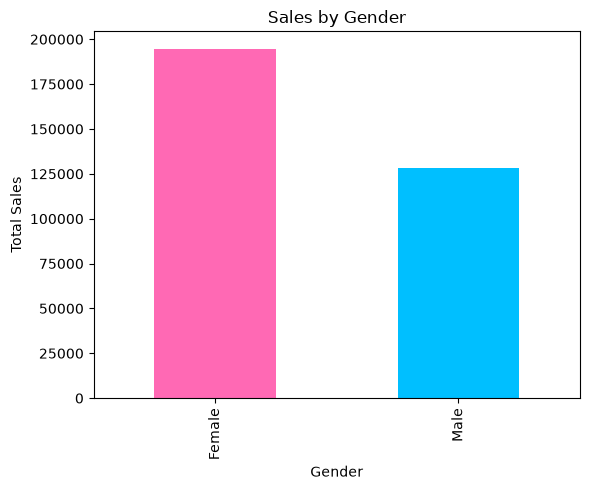

In [20]:
gender_sales = (
    df.groupby("Gender")["Sales"]
    .sum()
)

plt.figure(figsize=(6,5))

gender_sales.plot(
    kind="bar",
    color=["hotpink","deepskyblue"]
)

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("../reports/sales_by_gender.png", dpi=300)

plt.show()

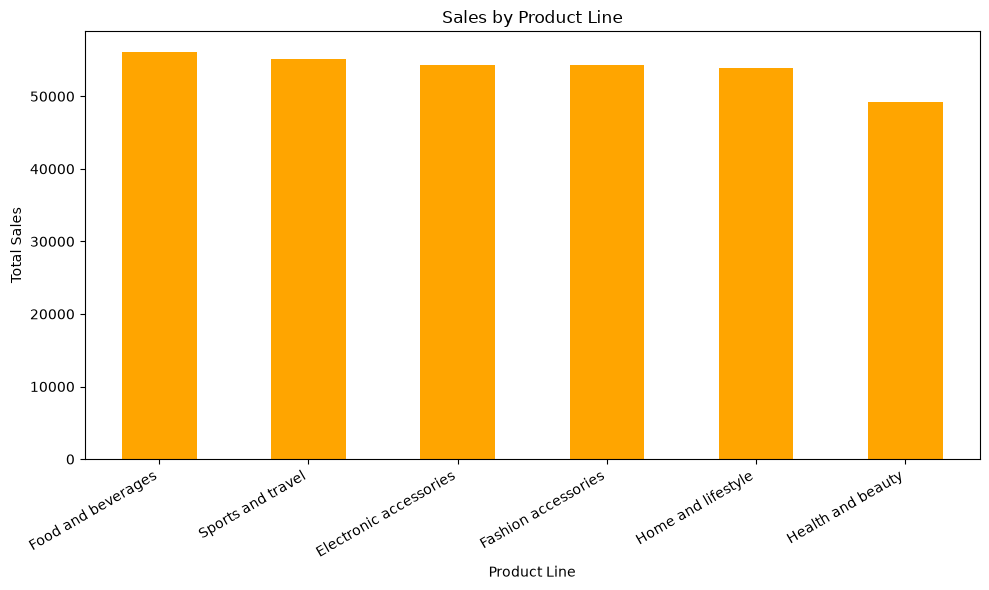

In [21]:
product_sales = (
    df.groupby("Product line")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

product_sales.plot(
    kind="bar",
    color="orange"
)

plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig("../reports/sales_by_product.png", dpi=300)

plt.show()

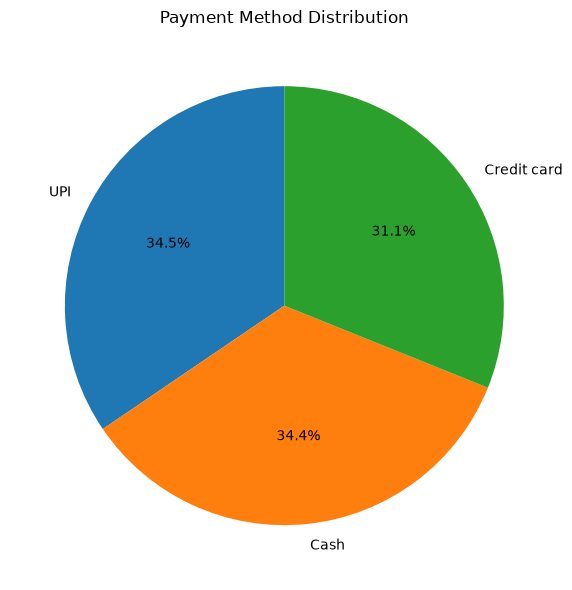

In [22]:
payment = df["Payment"].value_counts()

plt.figure(figsize=(6,6))

payment.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.tight_layout()

plt.savefig("../reports/payment_methods.png", dpi=300)

plt.show()

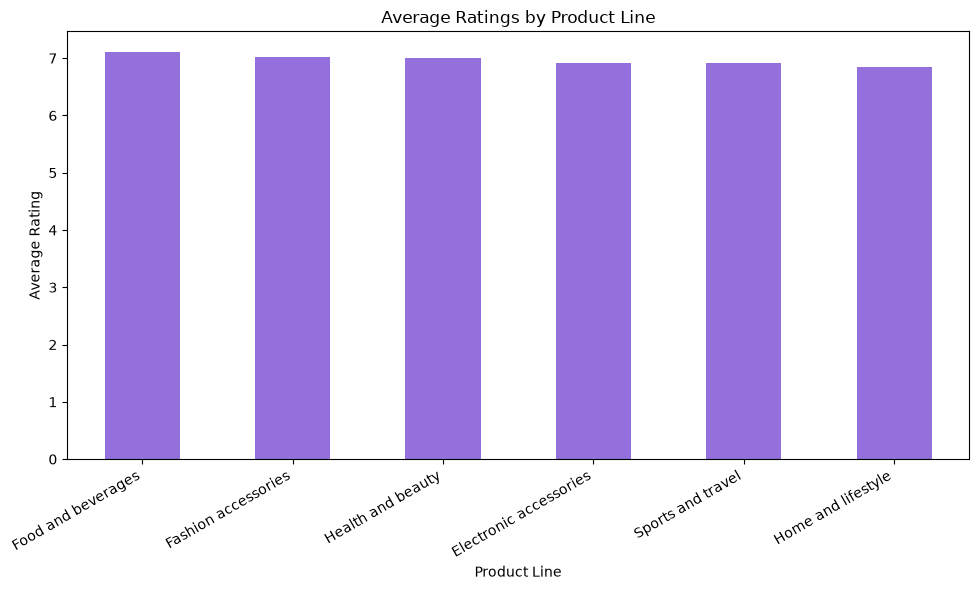

In [23]:
ratings = (
    df.groupby("Product line")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ratings.plot(
    kind="bar",
    color="mediumpurple"
)

plt.title("Average Ratings by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Rating")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig("../reports/ratings_by_product.png", dpi=300)

plt.show()

In [24]:
df["Hour"] = pd.to_datetime(
    df["Time"],
    format="%I:%M %p"
).dt.hour

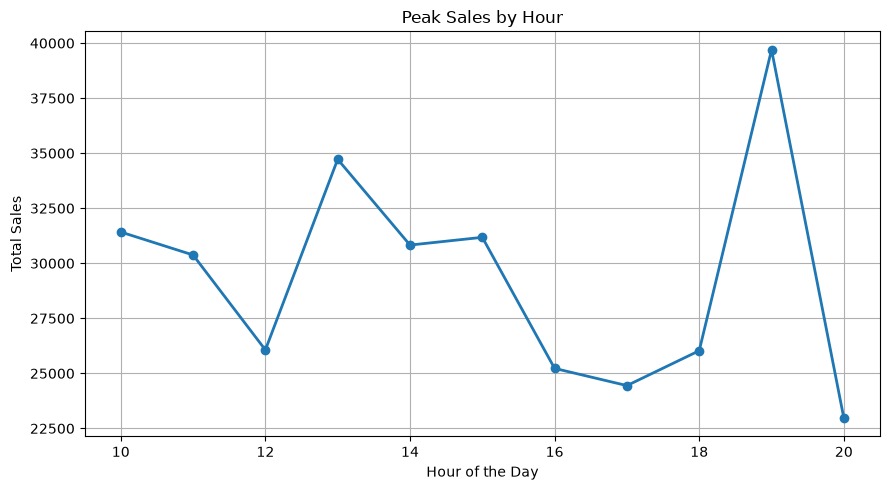

In [25]:
hour_sales = (
    df.groupby("Hour")["Sales"]
    .sum()
)

plt.figure(figsize=(9,5))

hour_sales.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Peak Sales by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/sales_by_hour.png", dpi=300)

plt.show()

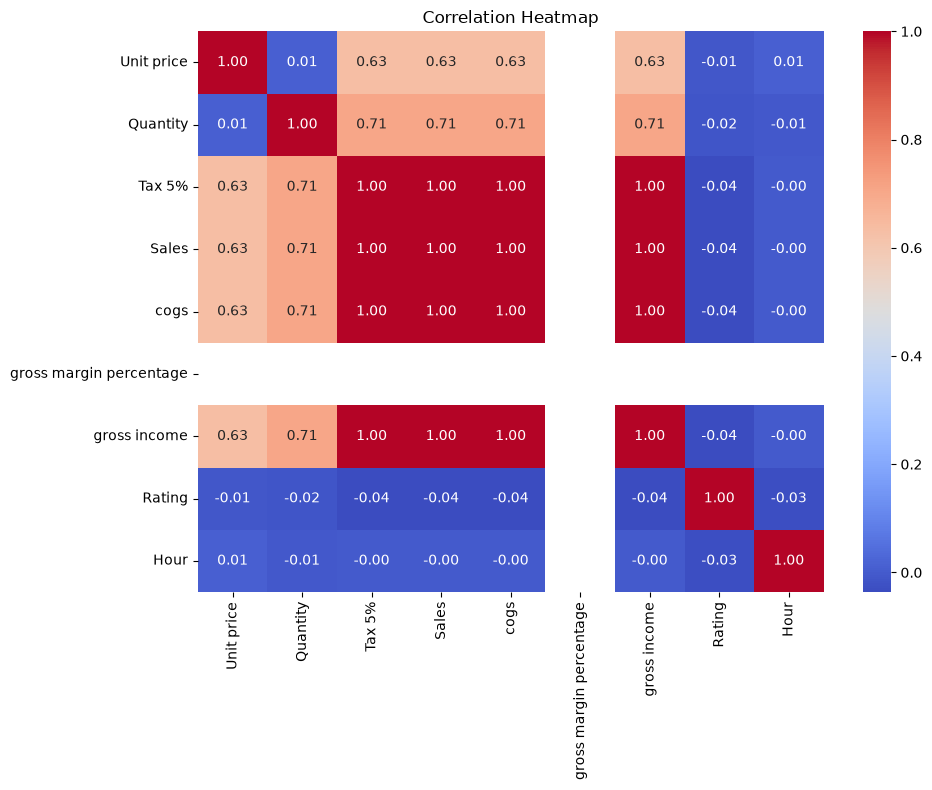

In [28]:
plt.figure(figsize=(10,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../reports/correlation_map.png", dpi=300)

plt.show()

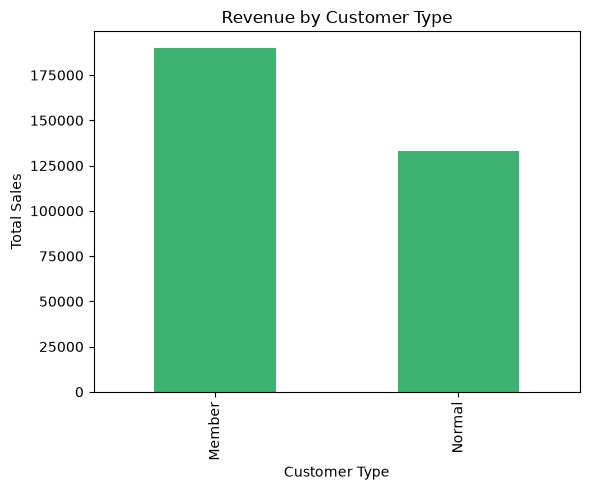

In [29]:
customer_sales = (
    df.groupby("Customer type")["Sales"]
    .sum()
)

plt.figure(figsize=(6,5))

customer_sales.plot(
    kind="bar",
    color="mediumseagreen"
)

plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("../reports/customer_type_sales.png", dpi=300)

plt.show()